In [3]:
import pandas as pd
import numpy as np

In [4]:
train_df = pd.read_csv('house_train.csv')
test_df = pd.read_csv('house_test.csv')

In [5]:
train_df.head()

,ID,Location,Paint_Color,Lot_Width,Lot_Depth,Year_Sold,Year_Built,Living_Area,Num_Rooms,Price
0,1,Suburb,Green,134,NaN,2020,1990,813,6,1548800.0
1,2,Downtown,Green,76,93.0,2025,2019,3093,6,1974800.0
2,3,Suburb,Yellow,91,83.0,2019,2003,2845,3,2466950.0
3,4,Suburb,Green,26,21.0,2022,1995,1837,3,968700.0
4,5,Rural,Red,138,85.0,2017,1980,4928,8,2570700.0


In [6]:
test_df.head()

,ID,Location,Paint_Color,Lot_Width,Lot_Depth,Year_Sold,Year_Built,Living_Area,Num_Rooms
0,2001,Rural,Green,106,131,2023,1980,1076,7
1,2002,Rural,Green,98,23,2016,1984,4828,2
2,2003,Downtown,Green,42,45,2020,2014,1405,5
3,2004,Rural,Red,100,36,2018,1991,4853,4
4,2005,Rural,Yellow,67,111,2021,2021,3512,6


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           2000 non-null   int64  
 1   Location     2000 non-null   object 
 2   Paint_Color  2000 non-null   object 
 3   Lot_Width    2000 non-null   int64  
 4   Lot_Depth    1721 non-null   float64
 5   Year_Sold    2000 non-null   int64  
 6   Year_Built   2000 non-null   int64  
 7   Living_Area  2000 non-null   int64  
 8   Num_Rooms    2000 non-null   int64  
 9   Price        2000 non-null   float64
dtypes: float64(2), int64(6), object(2)
memory usage: 156.4+ KB


In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           1000 non-null   int64 
 1   Location     1000 non-null   object
 2   Paint_Color  1000 non-null   object
 3   Lot_Width    1000 non-null   int64 
 4   Lot_Depth    1000 non-null   int64 
 5   Year_Sold    1000 non-null   int64 
 6   Year_Built   1000 non-null   int64 
 7   Living_Area  1000 non-null   int64 
 8   Num_Rooms    1000 non-null   int64 
dtypes: int64(7), object(2)
memory usage: 70.4+ KB


In [9]:
train_df.describe()

,ID,Lot_Width,Lot_Depth,Year_Sold,Year_Built,Living_Area,Num_Rooms,Price
count,2000.000000,2000.000000,1721.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,1000.500000,86.184000,85.052876,2019.956000,1995.939500,2855.676500,4.977000,2.310834e+06
std,577.494589,37.372256,37.156021,3.136875,14.735108,1196.761125,2.001118,1.781685e+06
min,1.000000,20.000000,20.000000,2015.000000,1966.000000,801.000000,2.000000,4.741000e+05
25%,500.750000,54.000000,52.000000,2017.000000,1983.000000,1837.000000,3.000000,1.414488e+06
50%,1000.500000,87.500000,87.000000,2020.000000,1996.000000,2808.500000,5.000000,2.020550e+06
75%,1500.250000,118.000000,116.000000,2023.000000,2008.000000,3865.000000,7.000000,2.679952e+06
max,2000.000000,149.000000,149.000000,2025.000000,2025.000000,4999.000000,8.000000,2.420700e+07


In [10]:
test_df.describe()

,ID,Lot_Width,Lot_Depth,Year_Sold,Year_Built,Living_Area,Num_Rooms
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2500.500000,84.340000,83.76600,2020.054000,1995.424000,2879.866000,4.922000
std,288.819436,37.527119,37.51187,3.124555,14.916928,1215.785852,2.007473
min,2001.000000,20.000000,20.00000,2015.000000,1967.000000,800.000000,2.000000
25%,2250.750000,52.000000,51.00000,2017.000000,1983.000000,1820.000000,3.000000
50%,2500.500000,86.000000,83.50000,2020.000000,1996.000000,2895.500000,5.000000
75%,2750.250000,117.000000,115.25000,2023.000000,2008.000000,3990.250000,7.000000
max,3000.000000,149.000000,149.00000,2025.000000,2024.000000,4993.000000,8.000000


In [11]:
print(train_df['Location'].nunique())
print(train_df['Paint_Color'].nunique())

3
4


In [12]:
train_df['Location'].unique()

array(['Suburb', 'Downtown', 'Rural'], dtype=object)

In [13]:
train_df['Lot_Depth'].isnull().sum()

np.int64(279)

In [14]:
train_df['Lot_Depth'].describe()

count    1721.000000
mean       85.052876
std        37.156021
min        20.000000
25%        52.000000
50%        87.000000
75%       116.000000
max       149.000000
Name: Lot_Depth, dtype: float64

In [15]:
train_df['Lot_Depth'] = train_df['Lot_Depth'].fillna(
    train_df.groupby('Location')['Lot_Depth'].transform('median')
)

In [16]:
test_df['Lot_Depth'] = test_df['Lot_Depth'].fillna(
    test_df.groupby('Location')['Lot_Depth'].transform('median')
)

In [17]:
train_df['Price'].describe()

count    2.000000e+03
mean     2.310834e+06
std      1.781685e+06
min      4.741000e+05
25%      1.414488e+06
50%      2.020550e+06
75%      2.679952e+06
max      2.420700e+07
Name: Price, dtype: float64

<Axes: ylabel='Price'>

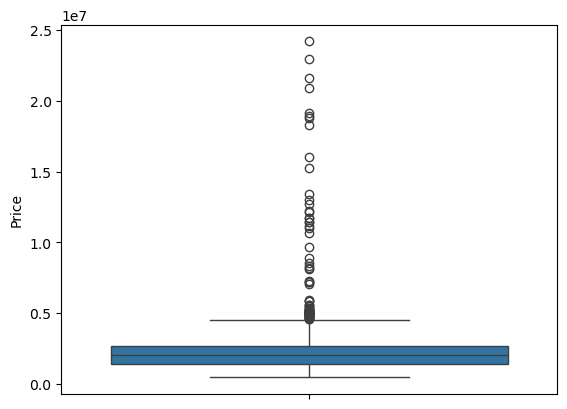

In [18]:
import seaborn as sns
sns.boxplot(train_df['Price'])

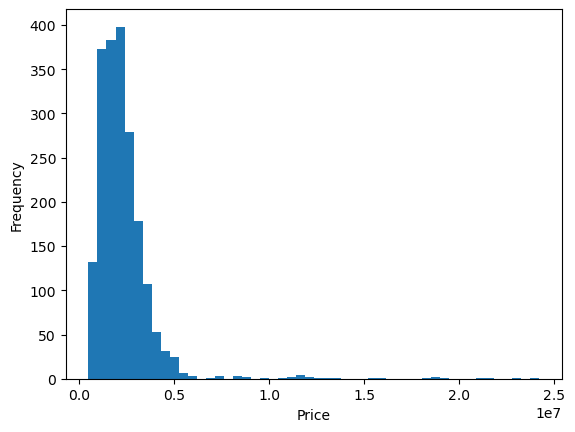

In [19]:
import matplotlib.pyplot as plt 
plt.hist(train_df['Price'], bins = 50)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [20]:
train_df['Price'] = np.log1p(train_df['Price'])

<Axes: ylabel='Price'>

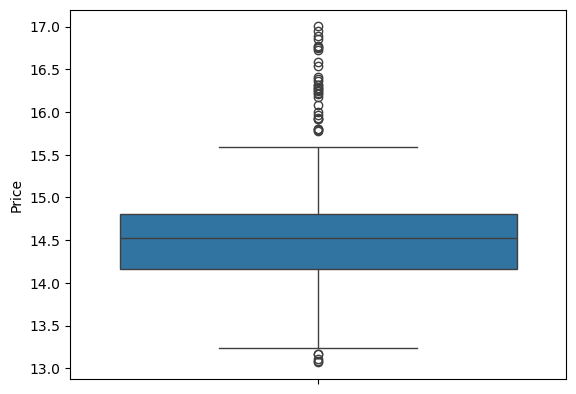

In [21]:
sns.boxplot(train_df['Price'])

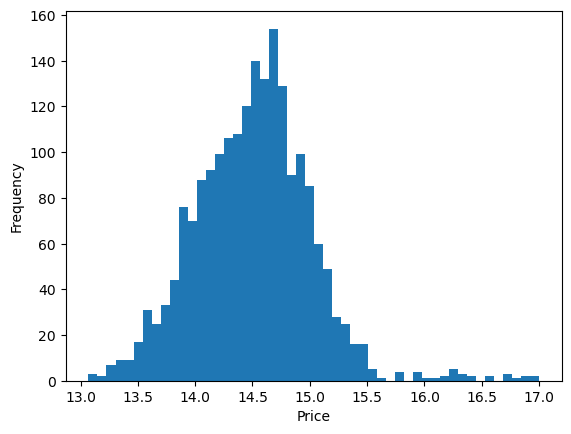

In [22]:
import matplotlib.pyplot as plt 
plt.hist(train_df['Price'], bins = 50)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [23]:
test_ID = test_df['ID']

In [24]:
train_df = train_df.drop('ID',axis =1 )

In [25]:
test_df = test_df.drop('ID',axis =1 )

## Encoding


In [26]:
train_df = pd.get_dummies(train_df , columns = ['Location'], dtype = int, drop_first = True)

In [27]:
test_df = pd.get_dummies(test_df , columns = ['Location'], dtype = int, drop_first = True)

In [28]:
# train_df = pd.get_dummies(train_df , drop_first = True, columns=['Paint_Color'], dtype = int)
train_df = train_df.drop('Paint_Color',axis = 1)
train_df = train_df.drop('Year_Sold',axis = 1)

In [29]:
test_df = test_df.drop('Paint_Color',axis = 1)
test_df = test_df.drop('Year_Sold',axis = 1)

In [30]:
train_df.head()

,Lot_Width,Lot_Depth,Year_Built,Living_Area,Num_Rooms,Price,Location_Rural,Location_Suburb
0,134,88.0,1990,813,6,14.252992,0,1
1,76,93.0,2019,3093,6,14.495978,0,0
2,91,83.0,2003,2845,3,14.718494,0,1
3,26,21.0,1995,1837,3,13.783711,0,1
4,138,85.0,1980,4928,8,14.759689,1,0


In [31]:
test_df.head()

,Lot_Width,Lot_Depth,Year_Built,Living_Area,Num_Rooms,Location_Rural,Location_Suburb
0,106,131,1980,1076,7,1,0
1,98,23,1984,4828,2,1,0
2,42,45,2014,1405,5,0,0
3,100,36,1991,4853,4,1,0
4,67,111,2021,3512,6,1,0


In [32]:
import statsmodels.api as sm
from statsmodels.tools import add_constant
x = train_df[['Lot_Width','Lot_Depth','Year_Built','Living_Area','Num_Rooms','Location_Rural','Location_Suburb']]
x = sm.add_constant(x)

Y = train_df['Price']

model = sm.OLS(Y,x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.666
Model:                            OLS   Adj. R-squared:                  0.665
Method:                 Least Squares   F-statistic:                     567.8
Date:                Tue, 18 Aug 2026   Prob (F-statistic):               0.00
Time:                        00:49:48   Log-Likelihood:                -386.20
No. Observations:                2000   AIC:                             788.4
Df Residuals:                    1992   BIC:                             833.2
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               9.2915      0.894     

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


In [34]:
X = train_df.drop('Price',axis = 1)
y = train_df['Price']

In [35]:
X_train , X_test, y_train , y_test = train_test_split(X,y, test_size= .2 , random_state=42)

In [36]:
print(X.shape)
print(y.shape)

(2000, 7)
(2000,)


In [37]:
lr = LinearRegression()

In [38]:
train_df

,Lot_Width,Lot_Depth,Year_Built,Living_Area,Num_Rooms,Price,Location_Rural,Location_Suburb
0,134,88.0,1990,813,6,14.252992,0,1
1,76,93.0,2019,3093,6,14.495978,0,0
2,91,83.0,2003,2845,3,14.718494,0,1
3,26,21.0,1995,1837,3,13.783711,0,1
4,138,85.0,1980,4928,8,14.759689,1,0
...,...,...,...,...,...,...,...,...
1995,145,60.0,1988,984,8,14.285890,0,1
1996,117,59.0,2002,1045,3,14.337544,0,0
1997,45,86.0,1990,1038,3,13.393460,1,0
1998,67,86.0,1970,1319,8,14.240975,1,0


In [39]:
lr.fit(X_train , y_train )

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
y_pred = lr.predict(X_test)

In [41]:
r2_score(y_test , y_pred )

0.6678031349262173

In [42]:
predictions = lr.predict(test_df)

In [43]:
submission = pd.DataFrame({
    'ID': test_ID,
    'Predicted_Price': predictions
})

In [44]:
submission.to_csv('submission.csv',index = False)

In [45]:
# train_df = train_df.drop('Paint_Color_Green',axis =1 )
# train_df = train_df.drop('Paint_Color_Red',axis =1 )
# train_df = train_df.drop('Paint_Color_Yellow',axis =1 )